In [1]:
import math
import os
import pickle
import sys
from typing import Union

import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn.functional as F
from PIL import Image
from IPython.display import display, clear_output
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

sys.path.append(os.path.abspath('..'))   # repo root: utils, metrics

from utils.utils import return_device

from stylegan_utils import add_stylegan_repo, load_stylegan2_ffhq256, tensor2img, img2tensor,

import warnings
warnings.filterwarnings('ignore', message='Failed to build CUDA kernels')

## StyleGAN2

In [3]:
device = return_device()

Device is cuda


In [4]:
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch

Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pack-reused 129 (from 2)
Receiving objects: 100% (131/131), 1.13 MiB | 5.01 MiB/s, done.
Resolving deltas: 100% (57/57), done.


In [5]:
add_stylegan_repo('./stylegan2-ada-pytorch')
G = load_stylegan2_ffhq256(device)

stylegan2-ffhq-256 model not found, downloading...


--2026-07-05 17:16:01--  https://api.ngc.nvidia.com/v2/models/org/nvidia/team/research/stylegan2/1/files?redirect=true&path=stylegan2-ffhq-256x256.pkl
Resolving api.ngc.nvidia.com (api.ngc.nvidia.com)... 54.218.215.118, 184.34.83.28
Connecting to api.ngc.nvidia.com (api.ngc.nvidia.com)|54.218.215.118|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://xfiles.ngc.nvidia.com/org/nvidia/team/research/models/stylegan2/versions/1/files/stylegan2-ffhq-256x256.pkl?ssec-algo=AES256&versionId=E1.07LMabbicK5r2be3dvQOOSjHcGvDU&ssec-key=cMbVuRlsenr4F5bZGHF9Ya6CW4m%2BnDOj39weGJx3nnX44Cbz1CJDyifK66M%2FVv%2BejZlK5F36%2F3eVFMBS0uB%2BMrju606zaaE6KNwUdQjhoUM%2F4rewM%2Bnikgo6BUa740Fz0%2BYOoQfRzDKL5iIjCS%2F6BHaQN3hW4gCQ70onOgYYDfIf%2FJJZ3j4uWASMUYn1zNfwgi0DMrN2T7IPQFWuB5xOprMJij9ZdCPgdayDciI%2FPrrrw9GSRY8GtgZIZHl%2F9%2Fq58iG%2FnV9B2LsuFDzcxeRotYigNoseu3EaFtssL0XyAyt19i4R%2B5xUVjtGUQumq6f%2FXsF0PZlVW%2BiOqMir6O%2BnyCK2gDgRgP%2BVjIfjbpidiT44di7mR443Sa3iyJVcHO7p%2BTaxAZm8S0

done


Generator(
  (synthesis): SynthesisNetwork(
    w_dim=512, num_ws=14, img_resolution=256, img_channels=3, num_fp16_res=4
    (b4): SynthesisBlock(
      resolution=4, architecture=skip
      (conv1): SynthesisLayer(
        in_channels=512, out_channels=512, w_dim=512, resolution=4, up=1, activation=lrelu
        (affine): FullyConnectedLayer(in_features=512, out_features=512, activation=linear)
      )
      (torgb): ToRGBLayer(
        in_channels=512, out_channels=3, w_dim=512
        (affine): FullyConnectedLayer(in_features=512, out_features=512, activation=linear)
      )
    )
    (b8): SynthesisBlock(
      resolution=8, architecture=skip
      (conv0): SynthesisLayer(
        in_channels=512, out_channels=512, w_dim=512, resolution=8, up=2, activation=lrelu
        (affine): FullyConnectedLayer(in_features=512, out_features=512, activation=linear)
      )
      (conv1): SynthesisLayer(
        in_channels=512, out_channels=512, w_dim=512, resolution=8, up=1, activation=lrelu
 

Setting up PyTorch plugin "bias_act_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


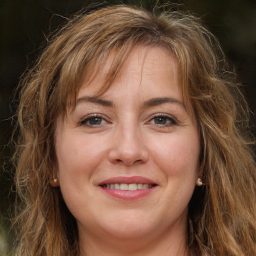

In [6]:
# Let's generate a random face by feeding random normally-distributed noise z (1x512) into the model

with torch.inference_mode():
    generator = torch.Generator(device).manual_seed(40)
    z = torch.randn([1, G.z_dim], generator=generator, device=device)
    c = None  # class
    img = G(z, c, truncation_psi=0.5, update_emas=False, noise_mode='const')

Image.fromarray(tensor2img(img)[0])

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


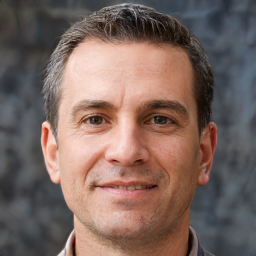

In [7]:
# The second way to generate 

with torch.inference_mode():
    generator = torch.Generator(device).manual_seed(42)
    z = torch.randn([1, G.z_dim], generator=generator, device=device)
    c = None
    # Map a random noise vector z (1x512) to a "latent vector" W (1 x 512) / W+ (1 x G.num_ws x 512) using the `MappingNetwork`
    wplus = G.mapping(z, c, truncation_psi=0.6, update_emas=False)
    img = G.synthesis(wplus, noise_mode='const')  # Use the `SynthesisNetwork` to generate.

Image.fromarray(tensor2img(img)[0])

In [8]:
# Let's explore how truncation_psi affects generation. 
# The larger the value, the further from the mean in W+ the result can be. 

@interact(
    seed=widgets.BoundedIntText(value=42, min=0, max=1e10, description="Seed: "),
    truncation_psi=widgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, continuous_update=False),
)

@torch.inference_mode()
def show_truncation_psi(seed: int, truncation_psi: float):
    generator = torch.Generator(device).manual_seed(seed)

    # Generate 2 random W+
    z1 = torch.randn([1, G.z_dim], generator=generator, device=device)
    wplus1 = G.mapping(z1, None, truncation_psi=truncation_psi, update_emas=False)

    img1 = tensor2img(G.synthesis(wplus1, noise_mode="const"))[0]

    return Image.fromarray(img1)

interactive(children=(BoundedIntText(value=42, description='Seed: ', max=10000000000), FloatSlider(value=0.5, …

In [9]:
# All 14 vectors are completely identical. 
# This happens because the MappingNetwork simply copies the same vector 14 times. 

wplus

tensor([[[ 0.1009,  0.0353, -0.0645,  ...,  0.0243, -0.0218, -0.0956],
         [ 0.1009,  0.0353, -0.0645,  ...,  0.0243, -0.0218, -0.0956],
         [ 0.1009,  0.0353, -0.0645,  ...,  0.0243, -0.0218, -0.0956],
         ...,
         [ 0.1009,  0.0353, -0.0645,  ...,  0.0243, -0.0218, -0.0956],
         [ 0.1009,  0.0353, -0.0645,  ...,  0.0243, -0.0218, -0.0956],
         [ 0.1009,  0.0353, -0.0645,  ...,  0.0243, -0.0218, -0.0956]]],
       device='cuda:0')

In [10]:
# Let's see what happens if we mix 2 different W+ vectors at some cutoff (at some level from 0 to 14). 

@interact(
    seed=widgets.BoundedIntText(value=42, min=0, max=1e10, description="Seed: "),
    truncation_psi=widgets.FloatSlider(min=0, max=1, step=0.01, value=0.7, continuous_update=False),
    mixing_level=widgets.IntSlider(min=0, max=G.num_ws, step=1, value=10, continuous_update=False),
)

@torch.inference_mode()
def show_style_mixing(seed: int, truncation_psi: float, mixing_level: int) -> Image.Image:
    generator = torch.Generator(device).manual_seed(seed)

    # Generate 2 random W+
    z1 = torch.randn([1, G.z_dim], generator=generator, device=device)
    z2 = torch.randn([1, G.z_dim], generator=generator, device=device)
    wplus1 = G.mapping(z1, None, truncation_psi=truncation_psi, update_emas=False)
    wplus2 = G.mapping(z2, None, truncation_psi=truncation_psi, update_emas=False)

    # Construct a blend of 2 latents at a cutoff
    wplus3 = wplus1.clone().detach()
    wplus3[:, G.num_ws-mixing_level:, :] = wplus2[:, 0, :]

    img1 = tensor2img(G.synthesis(wplus1, noise_mode="const"))[0]
    img2 = tensor2img(G.synthesis(wplus2, noise_mode="const"))[0]
    img3 = tensor2img(G.synthesis(wplus3, noise_mode="const"))[0]

    return Image.fromarray(np.hstack((img1, img2, img3)))

interactive(children=(BoundedIntText(value=42, description='Seed: ', max=10000000000), FloatSlider(value=0.7, …

### Latent mixing

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

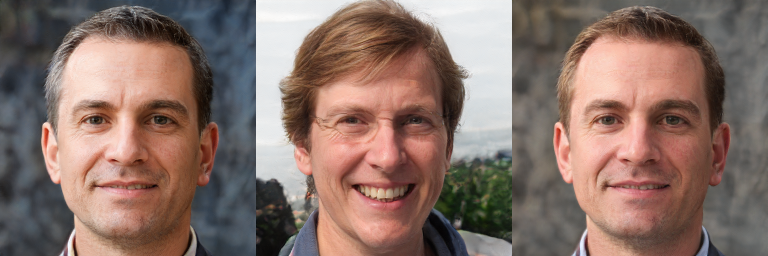

In [11]:
seed = 42
truncation_psi = 0.7

generator = torch.Generator(device).manual_seed(seed)

with torch.inference_mode():
    # Generate 2 random W+
    z1 = torch.randn([1, G.z_dim], generator=generator, device=device)
    z2 = torch.randn([1, G.z_dim], generator=generator, device=device)
    wplus1 = G.mapping(z1, None, truncation_psi=truncation_psi, update_emas=False)
    wplus2 = G.mapping(z2, None, truncation_psi=truncation_psi, update_emas=False)

    # In StyleGAN2 the "coarse" layers of W+ (corresponding to small synthesis resolutions, 4x4 - 16x16, i.e. indices ~0-3) control the overall 
    # pose, head shape and large-scale facial features; the "middle" layers (16x16 - 32x32, indices ~4-7) control hairstyle shape and facial 
    # features; and the "fine" layers (64x64 - 256x256, indices ~8-13) mainly control the color scheme (skin and hair color, lighting, background).
    #
    # So, to transfer pose/head shape/facial features/hair shape from the first image  while taking all colors from the second, we keep 
    # the "coarse" and "middle" layers from the first latent and replace the "fine" layers with the latent from the second image.
    
    mixing_level = 8  # chosen empirically by scanning values 0..14

    wplus3 = wplus1.clone().detach()
    wplus3[:, mixing_level:, :] = wplus2[:, 0, :]

    img1 = tensor2img(G.synthesis(wplus1, noise_mode="const"))[0]
    img2 = tensor2img(G.synthesis(wplus2, noise_mode="const"))[0]
    img3 = tensor2img(G.synthesis(wplus3, noise_mode="const"))[0]

result = Image.fromarray(np.hstack((img1, img2, img3)))
display(result)

In [12]:
@interact(
    seed=widgets.BoundedIntText(value=42, min=0, max=1e10, description="Seed: "),
    truncation_psi=widgets.FloatSlider(min=0, max=1, step=0.01, value=0.7, continuous_update=False),
    mixing_level_1=widgets.IntSlider(min=0, max=G.num_ws, step=1, value=7, continuous_update=False),
    mixing_level_2=widgets.IntSlider(min=0, max=G.num_ws, step=1, value=14, continuous_update=False),
)

@torch.inference_mode()
def show_latents_mixing(seed: int, truncation_psi: float, mixing_level_1: int, mixing_level_2: int) -> Image.Image:
    generator = torch.Generator(device).manual_seed(seed)

    # Generate 2 random W+
    z1 = torch.randn([1, G.z_dim], generator=generator, device=device)
    z2 = torch.randn([1, G.z_dim], generator=generator, device=device)
    wplus1 = G.mapping(z1, None, truncation_psi=truncation_psi, update_emas=False)
    wplus2 = G.mapping(z2, None, truncation_psi=truncation_psi, update_emas=False)

    # Construct a blend of 2 latents at a cutoff
    wplus3 = wplus1.clone().detach()
    wplus3[:, mixing_level_1:mixing_level_2, :] = wplus2[:, 0, :]

    img1 = tensor2img(G.synthesis(wplus1, noise_mode="const"))[0]
    img2 = tensor2img(G.synthesis(wplus2, noise_mode="const"))[0]
    img3 = tensor2img(G.synthesis(wplus3, noise_mode="const"))[0]

    return Image.fromarray(np.hstack((img1, img2, img3)))

interactive(children=(BoundedIntText(value=42, description='Seed: ', max=10000000000), FloatSlider(value=0.7, …

### Discovering interpretable directions in W

In [13]:
total_size, batch_size, total_generated = 1_000_000, 1_000, 0
latents = np.zeros((total_size, G.w_dim), dtype=np.float32)
generator = torch.Generator(device).manual_seed(42)

for _ in tqdm(range(math.ceil(total_size / batch_size))):
    num_latents = min(batch_size, total_size - total_generated)

    z = torch.randn([num_latents, G.z_dim], generator=generator, device=device)
    w = G.mapping(z, None, truncation_psi=1.0, update_emas=False)[:, 0, :].cpu().numpy()
    latents[total_generated:total_generated+num_latents] = w
    total_generated += num_latents

  0%|          | 0/1000 [00:00<?, ?it/s]

In [14]:
# Run PCA on our latents
pca = PCA(n_components=G.w_dim).fit(latents)
PCA_COMPONENTS = pca.components_
EXPLAINED_VARIANCE_RATIO = pca.explained_variance_ratio_

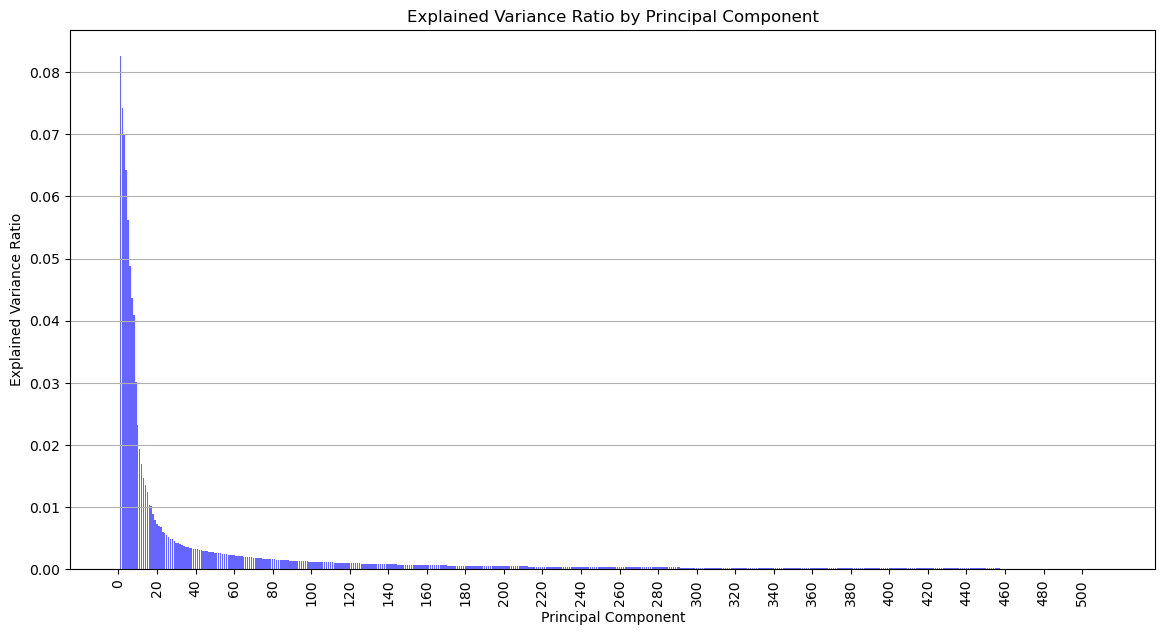

In [15]:
plt.figure(figsize=(14, 7))
plt.bar(np.arange(1, len(EXPLAINED_VARIANCE_RATIO) + 1), EXPLAINED_VARIANCE_RATIO, alpha=0.6, color='b')
plt.title('Explained Variance Ratio by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')

plt.xticks(np.arange(0, len(EXPLAINED_VARIANCE_RATIO) + 1, step=20), rotation=90)
plt.grid(axis='y')

plt.show()

In [16]:
@interact(
    seed=widgets.BoundedIntText(value=42, min=0, max=1e10, description="Seed: "),
    truncation_psi=widgets.FloatSlider(min=0, max=1, step=0.01, value=0.5, continuous_update=False),
    component_id=widgets.BoundedIntText(value=0, min=0, max=G.z_dim, description="Component: "),
    strength=widgets.FloatSlider(min=-5, max=5, step=0.1, value=3.0, continuous_update=False),
)
@torch.inference_mode()
def show_pca_components(seed: int, truncation_psi: float, component_id: int, strength: float):
    generator = torch.Generator(device).manual_seed(seed)

    # Generate 2 random W+
    z = torch.randn([1, G.z_dim], generator=generator, device=device)
    wplus = G.mapping(z, None, truncation_psi=truncation_psi, update_emas=False)

    # Apply the shift
    delta = torch.from_numpy(PCA_COMPONENTS[component_id]).reshape(1, 1, -1).to(device)
    wplus_shift = wplus + strength*delta

    img = tensor2img(G.synthesis(wplus, noise_mode="const"))[0]
    img_shift = tensor2img(G.synthesis(wplus_shift, noise_mode="const"))[0]

    return Image.fromarray(np.hstack((img, img_shift)))

interactive(children=(BoundedIntText(value=42, description='Seed: ', max=10000000000), FloatSlider(value=0.5, …